In [1]:
import pandas as pd
import numpy as np
import glob
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import os
import gudhi as gd
import pandas as pd
import glob
import os
from pathlib import Path
from scipy.stats import pearsonr
from numpy.linalg import eig
from numpy.linalg import eigh
import numpy as np
import datetime
from datetime import datetime, timedelta
import os, shutil
from numpy import nan
from itertools import groupby
import seaborn as sns
from scipy import linalg
import math
from sklearn.linear_model import LinearRegression
import pickle
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

In [2]:
def norm_beta(alpha, ref):

    beta = (alpha/(alpha - 1))
    return np.sum(np.abs(ref)**(beta))**(1/beta)

def g_ref(alpha, ref):
    norma_beta = norm_beta(alpha, ref)
    g = ref/(norma_beta + 1)
    return norm_beta(alpha, g)

def f_ref(ref):
    return ref**2

def finsler_metric(df, alpha, x, y):
    """
        Computes the Finsler metric between two columns of a DataFrame.

        The metric is composed of two terms:
        - A generalized distance term (an L^alpha norm weighted by f_ref).
        - An additional correction term depending on g_ref.

        Formula:
            M = (∑ f_ref(p_i) * |q_i - p_i|^α )^{1/α} + ∑ g_ref(α, p_i) * f_ref(p_i)^{1/α} * (q_i - p_i)

        Parameters
        ----------
        df : pandas.DataFrame
            DataFrame containing the vectors `p` and `q`.
        alpha : float
            Parameter of the L^alpha norm. Must be positive.
        x : str
            Name of the column used as vector `p` (reference).
        y : str
            Name of the column used as vector `q` (comparison).

        Returns
        -------
        float
            Scalar value of the Finsler metric between the vectors `p` and `q`.

        Notes
        -----
        - The functions `f_ref` and `g_ref` must be defined in the global scope.
        - The values in `df[x]` and
    """
    p = df[x].values
    q = df[y].values
    ref = p

    diff = np.abs(q - p)
    f = f_ref(ref)
    g = g_ref(alpha, ref)

    term1 = np.sum(f * (diff ** alpha)) ** (1 / alpha)
    term2 = np.sum(g * (f ** (1 / alpha)) * (q - p))
    
    return term1 

# LOADING MATRICES

In [3]:
all_files_finsler = glob.glob('finsler_matrixes/*.csv')


In [101]:
matrizes_dist_finsler = []
for filename in all_files_finsler:
    df = pd.read_csv(filename, index_col = None, header = 0, on_bad_lines='skip')
    matrizes_dist_finsler.append(df)

In [95]:
all_files_correlacao = glob.glob('correlarion_matrixes/*.csv')


In [103]:
matrizes_dist_corre = []
for filename in all_files_correlacao:
    df = pd.read_csv(filename, index_col = None, header = 0, on_bad_lines='skip')
    matrizes_dist_corre.append(df)

In [96]:
all_files_euclidean = glob.glob('euclidean_distances/*.csv')


In [104]:
matrizes_dist_euclidiana = []
for filename in all_files_euclidean:
    df = pd.read_csv(filename, index_col = None, header = 0, on_bad_lines='skip')
    matrizes_dist_euclidiana.append(df)

# LOADING MATRICES - END

# READING & ORGANISING DATA

In [5]:
all_files = glob.glob('stocks/*.csv')

In [7]:
li = []
for filename in all_files:
    df = pd.read_csv(filename, index_col = None, header = 0, on_bad_lines='skip')
    li.append(df)

In [9]:
for df in li:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    

In [10]:
df_list_horario = []
for df in li:
    mask_time = df['timestamp'].dt.strftime('%H:%M').between('09:30', '16:00')
    df_filtered = df.loc[mask_time].sort_values('timestamp').reset_index(drop=True)
    df_list_horario.append(df_filtered)
    

In [12]:
all_days = pd.date_range(start="2025-08-21", end="2025-09-19", freq="B")  # B = business days

# Create a list to store all timestamps
full_timestamps = []

for day in all_days:
    # Timestamps from 09:30 to 16:00
    daily_index = pd.date_range(
        start=day + pd.Timedelta(hours=9, minutes=30),
        end=day + pd.Timedelta(hours=16),
        freq="T"  # 1-minute bars
    )
    full_timestamps.extend(daily_index)  # add to the list

# Convert to a DatetimeIndex
full_idx = pd.DatetimeIndex(full_timestamps)

In [13]:
filled_list = []

for df in df_list_horario:
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()

    # Reindex to include all expected timestamps
    df = df.reindex(full_idx)

    # Forward-fill OHLC
    df[['open','high','low','close']] = df[['open','high','low','close']].ffill()

    # Fill remaining NaNs (at the start) with first available close price
    first_price = df['close'].dropna().iloc[0]
    df[['open','high','low','close']] = df[['open','high','low','close']].fillna(first_price)

    # Restore timestamp as a column
    df = df.reset_index().rename(columns={'index':'timestamp'})
    filled_list.append(df)


In [3]:
merged_df = filled_list[0][['timestamp']].copy()

# Add each close column from each dataframe
for i, df in enumerate(filled_list):
    merged_df[f'close_{i}'] = df['close'].values 

In [4]:
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])

# Extract date
merged_df['date'] = merged_df['timestamp'].dt.date

# Create list of per-day DataFrames
per_day_list = [
    group.drop(columns='date').reset_index(drop=True)
    for _, group in merged_df.groupby('date')
]

In [16]:
per_day_close = []
for df in per_day_list:
    df_new = df.drop(columns='timestamp')
    per_day_close.append(df_new)

In [19]:
per_day_close_transpose = []
for df in per_day_list:
    df_new = df.drop(columns='timestamp')
    df_new_transpose = df_new.T
    per_day_close_transpose.append(df_new_transpose)

# READING & ORGANISING DATA - END

# MATRICES COMPUTATION

In [1]:
dist_matr_euclidean_row = []
for n, df in enumerate(per_day_close_transpose):
    X = df.T.values
    
    dist_matrix = np.sqrt(((X[:, None, :] - X[None, :, :])**2).sum(axis=2))

    dist_matrix = pd.DataFrame(dist_matrix, index=df.columns, columns=df.columns)
    dist_matr_euclidean_row.append(dist_matrix)
    print(n)
    
dist_matr_euclidean_row.pop(7)

In [2]:
dist_matr_euclidean_column = []
for n, df in enumerate(per_day_close):
    X = df.T.values
    
    dist_matrix = np.sqrt(((X[:, None, :] - X[None, :, :])**2).sum(axis=2))

    dist_matrix = pd.DataFrame(dist_matrix, index=df.columns, columns=df.columns)
    dist_matr_euclidean_column.append(dist_matrix)
    print(n)
    
dist_matr_euclidean_column.pop(7)

In [6]:
def d_(x, y):
    return np.sqrt(np.sum((np.sqrt(x) - np.sqrt(y))**2))

raiz_matrix_row = []
for k, df in enumerate(per_day_close_transpose):
    ids = df.columns
    n = len(ids)

    matriz_dist = np.zeros((n, n))

    for i in range(n):
        x = df.iloc[:, i].values 
        for j in range(n):
            y = df.iloc[:, j].values
            dist = d_(x, y)
            matriz_dist[i, j] = dist
                
    df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
    raiz_matrix_row.append(df_matrix)
    print(k)

raiz_matrix_row.pop(7)

In [5]:
def d(x, y):
    return np.sqrt(np.sum((np.log(x) - np.log(y))**2))

log_matrix_row = []
for k, df in enumerate(per_day_close_transpose):
    ids = df.columns
    n = len(ids)

    matriz_dist = np.zeros((n, n))

    for i in range(n):
        x = df.iloc[:, i].values  # get data, not name
        for j in range(n):
            y = df.iloc[:, j].values
            dist = d(x, y)
            matriz_dist[i, j] = dist
                
    df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
    log_matrix_row.append(df_matrix)   # store as DataFrame
    print(k)

log_matrix_row.pop(7)


In [7]:
def d(x, y):
    return np.sqrt(np.sum((np.log(x) - np.log(y))**2))

log_matrix_column = []
for k, df in enumerate(per_day_close):
    ids = df.columns
    n = len(ids)

    matriz_dist = np.zeros((n, n))

    for i in range(n):
        x = df.iloc[:, i].values  
        for j in range(n):
            y = df.iloc[:, j].values
            dist = d(x, y)
            matriz_dist[i, j] = dist
                
    df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
    log_matrix_column.append(df_matrix)   
    print(k)

log_matrix_column.pop(7)

In [8]:
finsler_matrix_row = []
for k, df in enumerate(per_day_close_transpose):
    ids = df.columns
    n = len(ids)

    matriz_dist = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
                dist = finsler_metric(df, alpha=7, x=ids[i], y=ids[j])
                matriz_dist[i, j] = dist
                
                
    df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
    finsler_matrix_row.append(matriz_dist)
    print(k)
finsler_matrix_row.pop(7)

In [9]:
list_finsler_matrix_row_alpha = []
for r in list(range(3,21)):
    finsler_matrix_row = []
    for k, df in enumerate(per_day_close_transpose):
        ids = df.columns
        n = len(ids)

        matriz_dist = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                    dist = finsler_metric(df, alpha=r, x=ids[i], y=ids[j])
                    matriz_dist[i, j] = dist


        df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
        finsler_matrix_row.append(matriz_dist)
        print(k)
    finsler_matrix_row.pop(7)
    list_finsler_matrix_row_alpha.append(finsler_matrix_row)

In [10]:
finsler_matrix_column = []
for k, df in enumerate(per_day_close):
    ids = df.columns
    n = len(ids)

    matriz_dist = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
                dist = finsler_metric(df, alpha=7, x=ids[i], y=ids[j])
                matriz_dist[i, j] = dist
                
                
    df_matrix = pd.DataFrame(matriz_dist, index=ids, columns=ids)
    finsler_matrix_column.append(matriz_dist)
    print(k)
finsler_matrix_column.pop(7)

In [11]:
corr_matr_row = []
for n, df in enumerate(per_day_close_transpose):
    matr_cor = df.corr()
    matr_cor_abs = matr_cor.abs()
    corr_matr_row.append(matr_cor_abs)
    print(n)
    
corr_matr_row.pop(7)

In [12]:
corr_matr_column = []
for n, df in enumerate(per_day_close):
    matr_cor = df.corr()
    matr_cor_abs = matr_cor.abs()
    corr_matr_column.append(matr_cor_abs)
    print(n)
    
corr_matr_column.pop(7)

# MATRICES COMPUTATION - END

# PERSISTENCE COMPUTATION

In [14]:
H1_log_stocks_column = []
percentages_max_H1_log_column = []
for n, df in enumerate(log_matrix_column):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_log_column.append(pct)
    H1_log_stocks_column.append(len(H1))
    print(n)

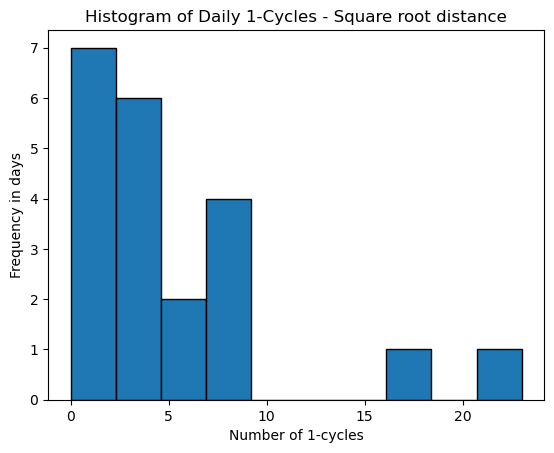

In [628]:
cycles_per_day = H1_raiz_stocks_row

bins = range(min(cycles_per_day), max(cycles_per_day)+2)
plt.hist(cycles_per_day, edgecolor='black')
plt.xlabel('Number of 1-cycles')
plt.ylabel('Frequency in days')
plt.yticks(range(0, int(plt.ylim()[1])+1))
plt.title('Histogram of Daily 1-Cycles - Square root distance')
plt.show()

In [15]:

H1_raiz_stocks_row = []
percentages_max_H1_raiz_row = []
for n, df in enumerate(raiz_matrix_row):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_raiz_row.append(pct)
    H1_raiz_stocks_row.append(len(H1))
    print(n)

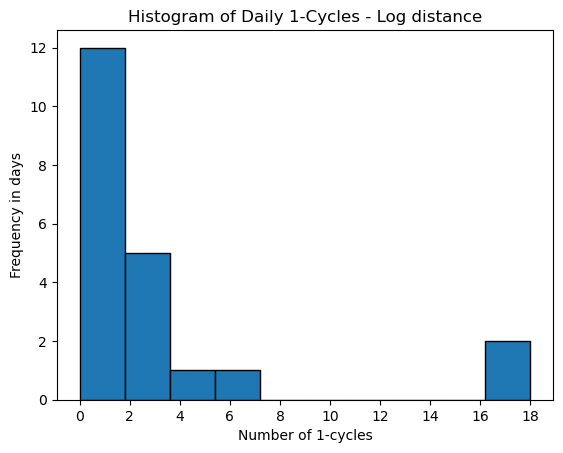

In [627]:
cycles_per_day = H1_log_stocks_row

plt.hist(cycles_per_day, edgecolor='black')

plt.xlabel('Number of 1-cycles')
plt.ylabel('Frequency in days')
plt.title('Histogram of Daily 1-Cycles - Log distance')

# Force x-axis to show only integer ticks
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [16]:
H1_log_stocks_row = []
percentages_max_H1_log_row = []
for n, df in enumerate(log_matrix_row):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_log_row.append(pct)
    H1_log_stocks_row.append(len(H1))
    print(n)

In [17]:
H1_euclidean_stocks_column = []
percentages_max_H1_euclidean_column = []
for n, df in enumerate(dist_matr_euclidean_column):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_euclidean_column.append(pct)
    H1_euclidean_stocks_column.append(len(H1))
    print(n)

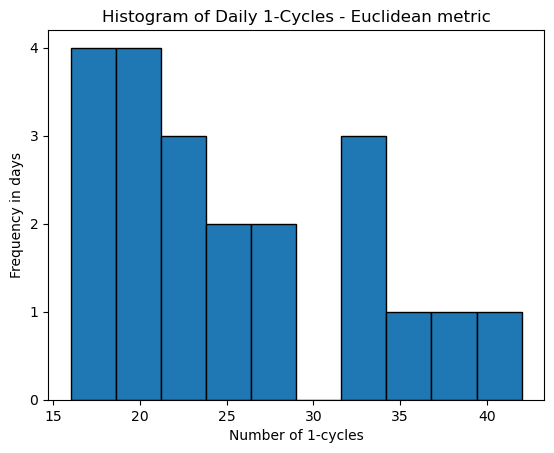

In [609]:
cycles_per_day = H1_euclidean_stocks_row


plt.hist(cycles_per_day, edgecolor='black')
plt.xlabel('Number of 1-cycles')
plt.ylabel('Frequency in days')
plt.yticks(range(0, int(plt.ylim()[1])+1))
plt.title('Histogram of Daily 1-Cycles - Euclidean metric')
plt.show()

In [18]:
H1_euclidean_stocks_row = []
percentages_max_H1_euclidean_row = []
for n, df in enumerate(dist_matr_euclidean_row):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_euclidean_row.append(pct)
    H1_euclidean_stocks_row.append(len(H1))
    print(n)

In [19]:
H1_correlation_stocks_column = []
percentages_max_H1_corr_column = []
for n, df in enumerate(corr_matr_column):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:  # no 1-cycles
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_corr_column.append(pct)
    H1_correlation_stocks_column.append(len(H1))
    print(n)

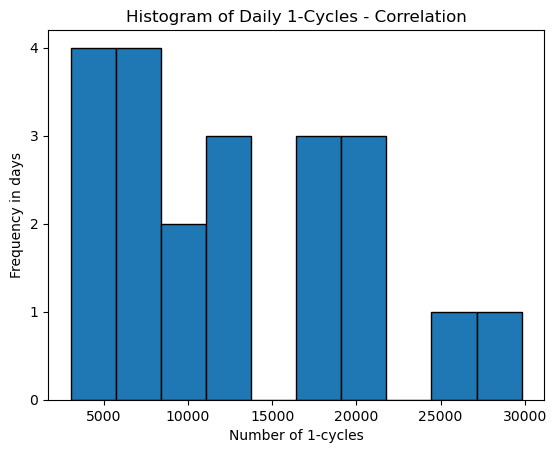

In [608]:


cycles_per_day = H1_correlation_stocks_row


plt.hist(cycles_per_day, edgecolor='black')
plt.xlabel('Number of 1-cycles')
plt.ylabel('Frequency in days')
plt.yticks(range(0, int(plt.ylim()[1])+1))
plt.title('Histogram of Daily 1-Cycles - Correlation')
plt.show()

In [20]:
H1_correlation_stocks_row = []
percentages_max_H1_corr_row = []
for n, df in enumerate(corr_matr_row):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_corr_row.append(pct)
    H1_correlation_stocks_row.append(len(H1))
    print(n)

In [21]:
H1_finsler_stocks_column = []
percentages_max_H1_finsler_column = []
for n, df in enumerate(finsler_matrix_column):
    df = pd.DataFrame(df)
    ids = df.columns
    df_matrix = pd.DataFrame(df, index=ids, columns=ids)
    M_upper = np.triu(df_matrix) + np.triu(df_matrix, k=1).T
    diagrams = ripser(M_upper, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:  
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_finsler_column.append(pct)
    H1_finsler_stocks_column.append(len(H1))
    print(n)

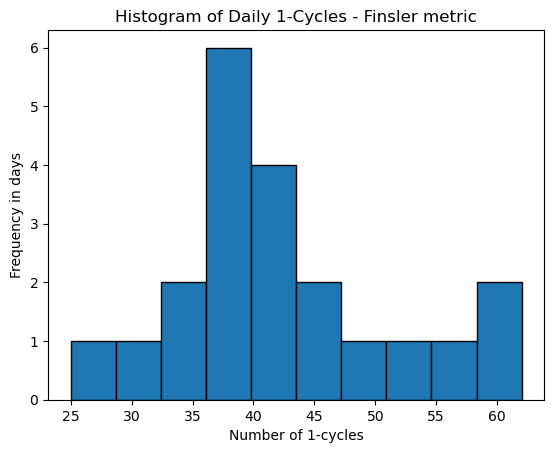

In [607]:
cycles_per_day = H1_finsler_stocks_row


plt.hist(cycles_per_day, edgecolor='black')
plt.xlabel('Number of 1-cycles')
plt.ylabel('Frequency in days')
plt.yticks(range(0, int(plt.ylim()[1])+1))
plt.title('Histogram of Daily 1-Cycles - Finsler metric')
plt.show()

In [22]:
H1_finsler_stocks_row = []
percentages_max_H1_finsler_row = []
for n, df in enumerate(finsler_matrix_row):
    df = pd.DataFrame(df)
    ids = df.columns
    df_matrix = pd.DataFrame(df, index=ids, columns=ids)
    M_upper = np.triu(df_matrix) + np.triu(df_matrix, k=1).T
    diagrams = ripser(M_upper, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:  
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_finsler_row.append(pct)
    H1_finsler_stocks_row.append(len(H1))
    print(n)

In [23]:
list_H1_finsler_stocks_row = []
list_percentages_max_H1_finsler_row = []
for k in list(range(0,len(list_finsler_matrix_row_alpha))):
    matrix_alpha = list_finsler_matrix_row_alpha[k]
    H1_finsler_stocks_row = []
    percentages_max_H1_finsler_row = []
    for n, df in enumerate(matrix_alpha):
        df = pd.DataFrame(df)
        ids = df.columns
        df_matrix = pd.DataFrame(df, index=ids, columns=ids)
        M_upper = np.triu(df_matrix) + np.triu(df_matrix, k=1).T
        diagrams = ripser(M_upper, distance_matrix=True)['dgms']
        H1 = diagrams[1]
        if H1.size == 0:  
            pct = 0.0
        else:
            lifetimes = H1[:, 1] - H1[:, 0]
            total_filtration = H1[:, 1].max()
            max_life = lifetimes.max()
            pct = (max_life / total_filtration) * 100

        percentages_max_H1_finsler_row.append(pct)
        H1_finsler_stocks_row.append(len(H1))
        print(n)
    list_H1_finsler_stocks_row.append(H1_finsler_stocks_row)
    list_percentages_max_H1_finsler_row.append(percentages_max_H1_finsler_row)

# PERSISTENCE COMPUTATION - END

# VOLATILITY

In [252]:
volatilidades = []
for df in per_day_close:
    returns = np.log(df / df.shift(1))
    market_return = returns.mean(axis=1)
    volatility = market_return.std()
    volatilidades.append(volatility)
    

# VOLATILITY - END

# PLOTTING

In [434]:
lists = [
    volatilidades,
    
    H1_finsler_stocks_row,
    percentages_max_H1_finsler_row,
    
    H1_finsler_stocks_column,
    percentages_max_H1_finsler_column,
    
    H1_correlation_stocks_row,
    percentages_max_H1_corr_row,
    
    H1_correlation_stocks_column,
    percentages_max_H1_corr_column,
    
    H1_euclidean_stocks_row,
    percentages_max_H1_euclidean_row,
    
    H1_euclidean_stocks_column,
    percentages_max_H1_euclidean_column
]

epsilon = 1e-10

logs_of_lists = [np.log(np.array(lst) + epsilon) for lst in lists]



In [440]:
df_lists = pd.DataFrame({f'list_{i+1}': lst for i, lst in enumerate(lists)})

In [580]:
df_list_percentages_max_H1_finsler_row = pd.DataFrame({f'list_{i+1}': lst for i, lst in enumerate(list_percentages_max_H1_finsler_row)})

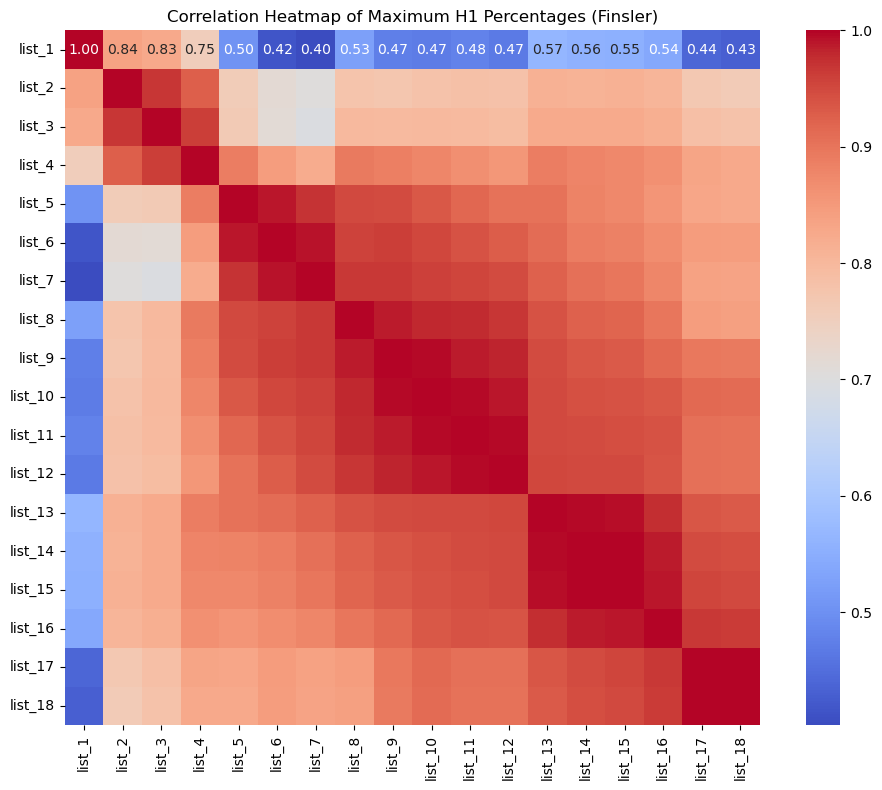

In [583]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_list_percentages_max_H1_finsler_row.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # blue-red colormap
    cbar=True,
    square=True
)

plt.title("Correlation Heatmap of Maximum H1 Percentages (Finsler)")
plt.tight_layout()
plt.show()

In [437]:
logs_of_lists_as_lists = [arr.tolist() for arr in logs_of_lists]

In [438]:
df_log_lists = pd.DataFrame({f'list_{i+1}': lst for i, lst in enumerate(logs_of_lists_as_lists)})

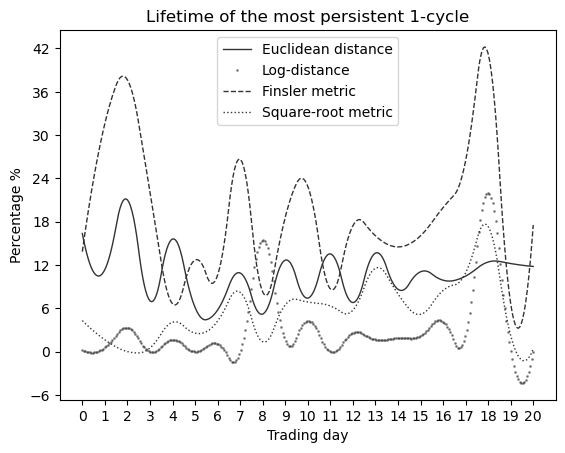

In [532]:
list1 = percentages_max_H1_euclidean_row
list2 = percentages_max_H1_log_row
list3 = percentages_max_H1_finsler_row
list4 = percentages_max_H1_raiz_row

x = np.arange(len(list1))
x_smooth = np.linspace(x.min(), x.max(), 300)

# Define styles for each curve (need 4, not 3)
styles = [
    {"linestyle": "-", "marker": None, "alpha": 1.0},   # Euclidean
    {"linestyle": "None", "marker": "o", "alpha": 0.5, "markersize": 1},  # Log
    {"linestyle": "--", "marker": None, "alpha": 1.0},  # Finsler
    {"linestyle": ":", "marker": None, "alpha": 1.0}    # Raiz
]

color = "#333333"  # dark grey for all

for y, label, style in zip(
    [list1, list2, list3, list4],
    ['Euclidean distance', 'Log-distance', 'Finsler metric', 'Square-root metric'],
    styles
):
    spline = make_interp_spline(x, y, k=2)  
    y_smooth = spline(x_smooth)
    plt.plot(
        x_smooth, y_smooth,
        label=label,
        linewidth=1,
        linestyle=style["linestyle"],
        marker=style.get("marker"),
        markersize=style.get("markersize", 3),
        alpha=style["alpha"],
        color=color
    )

# X-axis: integer ticks
plt.xticks(x)  

# Y-axis: more ticks
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=False, nbins=10)) 
plt.xlabel("Trading day")
plt.ylabel("Percentage %")
plt.title('Lifetime of the most persistent 1-cycle')
plt.legend()
plt.show()

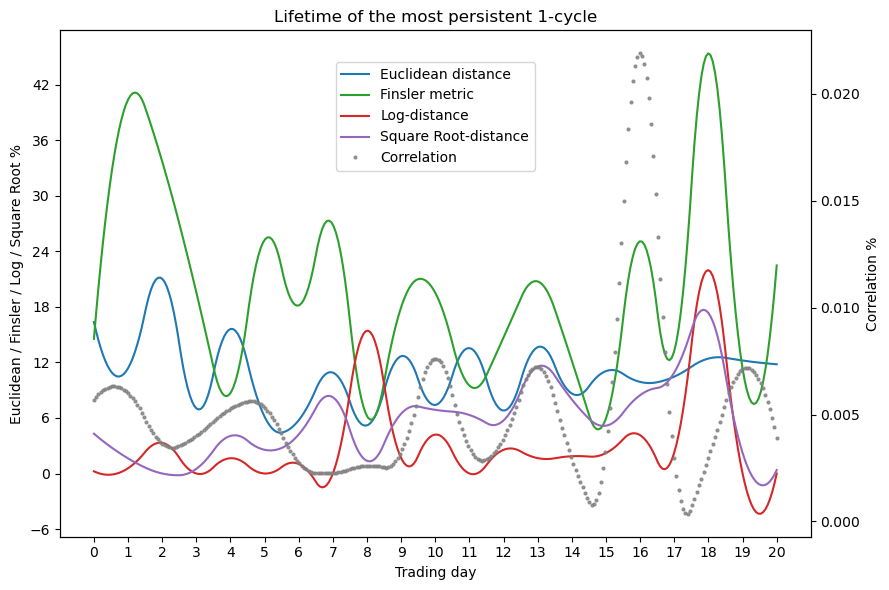

In [574]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.interpolate import make_interp_spline

# Your lists
list1 = percentages_max_H1_euclidean_row
list2 = percentages_max_H1_corr_row
list3 = percentages_max_H1_finsler_row
list4 = percentages_max_H1_log_row
list5 = percentages_max_H1_raiz_row  

x = np.arange(len(list1))
x_smooth = np.linspace(x.min(), x.max(), 300)

fig, ax1 = plt.subplots(figsize=(9,6))

# Color palette
colors = {
    "Euclidean distance": "#1f77b4",   # blue
    "Finsler metric":     "#2ca02c",   # green
    "Log-distance":       "#d62728",   # red
    "Square Root-distance":        "#9467bd",   # purple
    "Correlation":        "grey"       # grey for secondary axis
}

# Plot main metrics
for y, label in zip(
    [list1, list3, list4, list5],
    ['Euclidean distance', 'Finsler metric', 'Log-distance', 'Square Root-distance']
):
    spline = make_interp_spline(x, y, k=2)
    y_smooth = spline(x_smooth)
    ax1.plot(
        x_smooth, y_smooth,
        label=label,
        linewidth=1.5,
        color=colors[label]
    )

ax1.set_xlabel("Trading day")
ax1.set_ylabel("Euclidean / Finsler / Log / Square Root %")
ax1.set_xticks(x)
ax1.yaxis.set_major_locator(MaxNLocator(integer=False, nbins=10))

# Secondary axis for correlation
spline_corr = make_interp_spline(x, list2, k=2)
y_corr_smooth = spline_corr(x_smooth)
ax2 = ax1.twinx()
ax2.plot(
    x_smooth, y_corr_smooth,
    label="Correlation",
    linewidth=1.2,
    linestyle="None",
    marker="o",
    markersize=2,
    alpha=0.8,
    color=colors["Correlation"]
)
ax2.set_ylabel("Correlation %")

# Merge legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='center', bbox_to_anchor=(0.5, 0.83), borderaxespad=1)

plt.title('Lifetime of the most persistent 1-cycle')
plt.tight_layout()
plt.show()


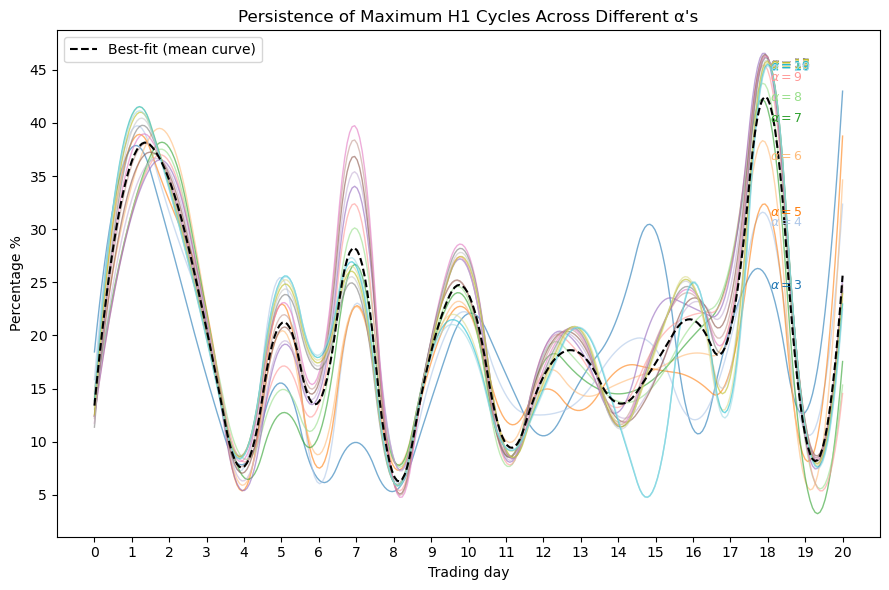

In [575]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.interpolate import make_interp_spline

# Your array
arr = np.array(list_percentages_max_H1_finsler_row)
x = np.arange(arr.shape[1])
x_smooth = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(9,6))

# Color palette
colors = plt.cm.tab20(np.linspace(0, 1, arr.shape[0]))

# Plot each curve with alpha labels slightly before the end
for i, y in enumerate(arr):
    spline = make_interp_spline(x, y, k=2)
    y_smooth = spline(x_smooth)
    ax.plot(
        x_smooth, y_smooth,
        linewidth=1,
        linestyle='-',
        color=colors[i],
        alpha=0.6
    )
    
    # Place label slightly inside the plot (not outside the box)
    ax.text(
        x_smooth[-30],            # 30 points before the last x
        y_smooth[-30],            # corresponding y
        fr"$\alpha = {i+3}$",     # LaTeX label
        fontsize=9,
        color=colors[i],
        va="center",
        ha="left"
    )

# Mean curve (best-fit)
mean_curve = arr.mean(axis=0)
spline_mean = make_interp_spline(x, mean_curve, k=2)
mean_smooth = spline_mean(x_smooth)

ax.plot(
    x_smooth, mean_smooth,
    label="Best-fit (mean curve)",
    linewidth=1.5,
    color="black",
    linestyle="--"
)

# Axes labels and formatting
ax.set_xlabel("Trading day")
ax.set_ylabel("Percentage %")
ax.set_xticks(x)
ax.yaxis.set_major_locator(MaxNLocator(integer=False, nbins=10))

# Only keep legend for mean curve
ax.legend(loc="best")

plt.title("Persistence of Maximum ​H1​ Cycles Across Different α's")
plt.tight_layout()
plt.show()


# PLOTTING - END